In [1]:
from pathlib import Path

import xarray as xr
import rioxarray
import xproj
import ndpyramid
import topozarr

import matplotlib
import matplotlib.pyplot as plt


In [2]:
print(f'Xarray    : {xr.__version__}')
print(f'ndpyramid : {ndpyramid.__version__}')
print(f'topozarr  : {topozarr.__version__}')


Xarray    : 2026.7.0
ndpyramid : 0.4.0
topozarr  : 0.1.5


## Read in `WorldClim` data

In [3]:
data_dir = Path('./data/worldclim/')
[path for path in list(data_dir.glob('*')) if 'wc' in str(path)]


[PosixPath('data/worldclim/wc2.1_5m_tavg'),
 PosixPath('data/worldclim/wc2.1_5m_tmax'),
 PosixPath('data/worldclim/wc2.1_5m_prec'),
 PosixPath('data/worldclim/wc2.1_5m_tmin')]

In [4]:


def open_worldclim_data(path: str, var: str, res: str, version: float) -> xr.Dataset:
    """
    This method takes in one of the available datasets (i.e., `var`) from 
    WorldClim at a given resolution and returns a Xarray Dataset 
    containing all 12 months containing climate averages for each month.

    https://worldclim.org/data/worldclim21.html

    This method assumes that you have downloaded the necessary datasets
    locally and that they are stored within the `path` directory.
    """
    months = list(range(1, 13))

    ds = xr.concat(
        [xr.open_dataset(f'{path}/wc{version}_{res}_{var}/wc{version}_{res}_{var}_{str(month).zfill(2)}.tif', engine='rasterio') for month in months],
        dim='month'
    )

    # add time dim to dataset coordinates
    ds = ds.assign_coords(month=months)

    # remove the 'band' dim from the dataset
    ds = ds.sel(band=1).drop_vars('band')

    # rename data variable
    ds = ds.rename({'band_data': var})

    # set crs
    ds = ds.proj.assign_crs(spatial_ref=4326)

    return ds


In [6]:
# open historical climate data from WorldClim v2.1 at 5 minute resolution
precip = open_worldclim_data(data_dir, 'prec', '5m', 2.1).rename({'prec': 'precip'})
tmin = open_worldclim_data(data_dir, 'tmin', '5m', 2.1)
tavg = open_worldclim_data(data_dir, 'tavg', '5m', 2.1)
tmax = open_worldclim_data(data_dir, 'tmax', '5m', 2.1)

ds_dict = {'tmin': tmin, 'tavg': tavg, 'tmax': tmax, 'precip': precip}


In [7]:
precip


<xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, y: 2160, x: 4320)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 17kB 89.96 89.88 89.79 ... -89.79 -89.87 -89.96
  * x            (x) float64 35kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
  * spatial_ref  int64 8B 0
Data variables:
    precip       (month, y, x) float32 448MB nan nan nan nan ... 0.0 0.0 0.0 0.0
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [8]:
tmin


<xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, y: 2160, x: 4320)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 17kB 89.96 89.88 89.79 ... -89.79 -89.87 -89.96
  * x            (x) float64 35kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
  * spatial_ref  int64 8B 0
Data variables:
    tmin         (month, y, x) float32 448MB nan nan nan ... -18.8 -18.8 -16.51
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [9]:
tavg


<xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, y: 2160, x: 4320)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 17kB 89.96 89.88 89.79 ... -89.79 -89.87 -89.96
  * x            (x) float64 35kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
  * spatial_ref  int64 8B 0
Data variables:
    tavg         (month, y, x) float32 448MB nan nan nan ... -16.54 -14.51
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [10]:
tmax


<xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, y: 2160, x: 4320)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 17kB 89.96 89.88 89.79 ... -89.79 -89.87 -89.96
  * x            (x) float64 35kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
  * spatial_ref  int64 8B 0
Data variables:
    tmax         (month, y, x) float32 448MB nan nan nan ... -14.26 -12.52
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

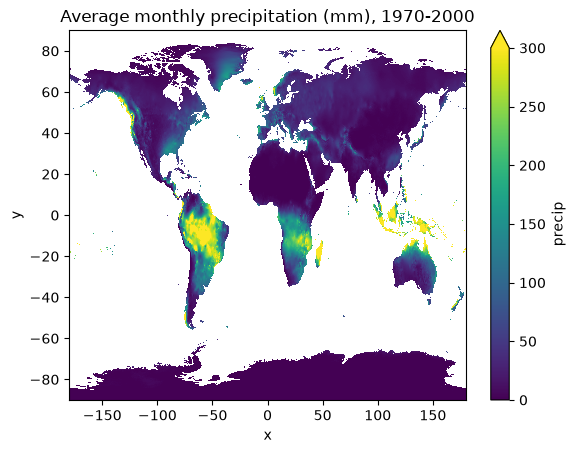

In [11]:
fig, ax = plt.subplots()

precip.sel(month=1).precip.plot(vmin=0, vmax=300, ax=ax)
ax.set_title('Average monthly precipitation (mm), 1970-2000')

plt.show()


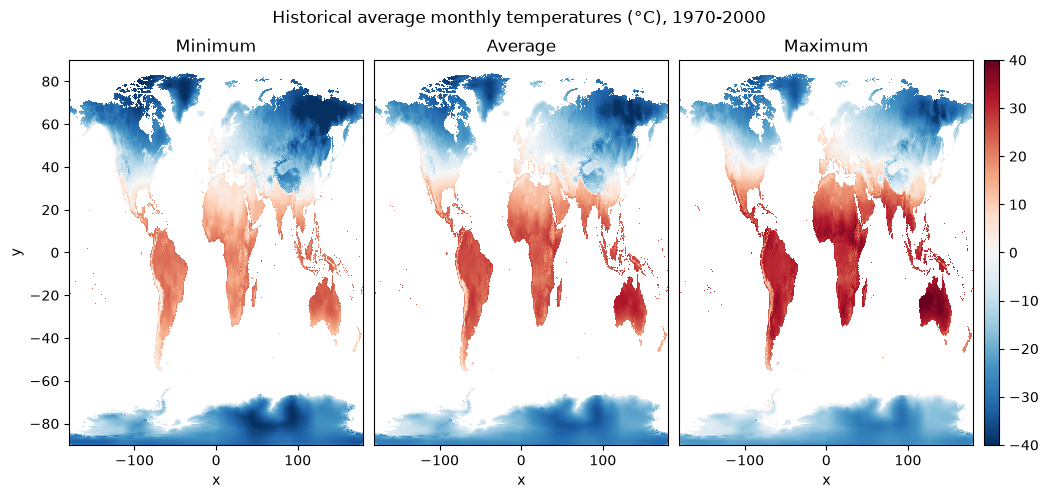

In [12]:
vmin= -40
vmax = 40
cmap = 'RdBu_r'
data_vars = ['tmin', 'tavg', 'tmax', 'prec']

fig = plt.figure(figsize=(12, 5))
axes_dict = fig.subplot_mosaic(
    'ABCD',
    width_ratios=[10, 10, 10, 0.5,],
    gridspec_kw={'hspace':0.05, 'wspace':0.05}
)

cax = axes_dict['D']

for var, ax_name in zip(data_vars[:3], list(axes_dict.keys())[:3]):
    ax = axes_dict[ax_name]

    ds_dict[var].sel(month=1)[var].plot(vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False, ax=ax)

    if ax_name in ['B', 'C']:
        # turn off y axis label and ticks
        ax.set_ylabel('')
        ax.set_yticks([])

axes_dict['A'].set_title('Minimum')
axes_dict['B'].set_title('Average')
axes_dict['C'].set_title('Maximum')
fig.suptitle('Historical average monthly temperatures (°C), 1970-2000')

colorbar = fig.colorbar(
    matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin, vmax), cmap=cmap),
    cax=cax
)

plt.show()
